In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

plt.style.use('ggplot')

In [2]:
df = pd.read_excel("C:/Users/basav/Downloads/marketing_campaign.xlsx")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [5]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df['Income'].fillna(df['Income'].median(), inplace=True)
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Customer_Tenure'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [10]:
df['Age'] = 2026 - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                            'MntFishProducts','MntSweetProducts',
                            'MntGoldProds']].sum(axis=1)

In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Customer_Tenure', 'Age', 'Total_Children', 'Total_Spending'],
      dtype='object')

In [12]:
print('number of unique values ')
print(f'Education : {df['Education'].nunique()}')
print(f'Marital_Status : {df['Marital_Status'].nunique()}')

number of unique values 
Education : 5
Marital_Status : 8


In [13]:
x = pd.get_dummies(df['Education'], prefix='Education', dtype = int)
df = pd.concat([df,x],axis = 1)
# df.drop('Education',axis = 1, inplace = True)

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

In [15]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Customer_Tenure,Age,Total_Children,Total_Spending,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,5524,1957,Graduation,4,58138.0,0,0,2012-09-04,58,635,...,1,663,69,0,1617,0,0,1,0,0
1,2174,1954,Graduation,4,46344.0,1,1,2014-03-08,38,11,...,0,113,72,2,27,0,0,1,0,0
2,4141,1965,Graduation,5,71613.0,0,0,2013-08-21,26,426,...,0,312,61,0,776,0,0,1,0,0
3,6182,1984,Graduation,5,26646.0,1,0,2014-02-10,26,11,...,0,139,42,1,53,0,0,1,0,0
4,5324,1981,PhD,3,58293.0,1,0,2014-01-19,94,173,...,0,161,45,1,422,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,3,61223.0,0,1,2013-06-13,46,709,...,0,381,59,1,1341,0,0,1,0,0
2236,4001,1946,PhD,5,64014.0,2,1,2014-06-10,56,406,...,0,19,80,3,444,0,0,0,0,1
2237,7270,1981,Graduation,2,56981.0,0,0,2014-01-25,91,908,...,0,155,45,0,1241,0,0,1,0,0
2238,8235,1956,Master,5,69245.0,0,1,2014-01-24,8,428,...,0,156,70,1,843,0,0,0,1,0


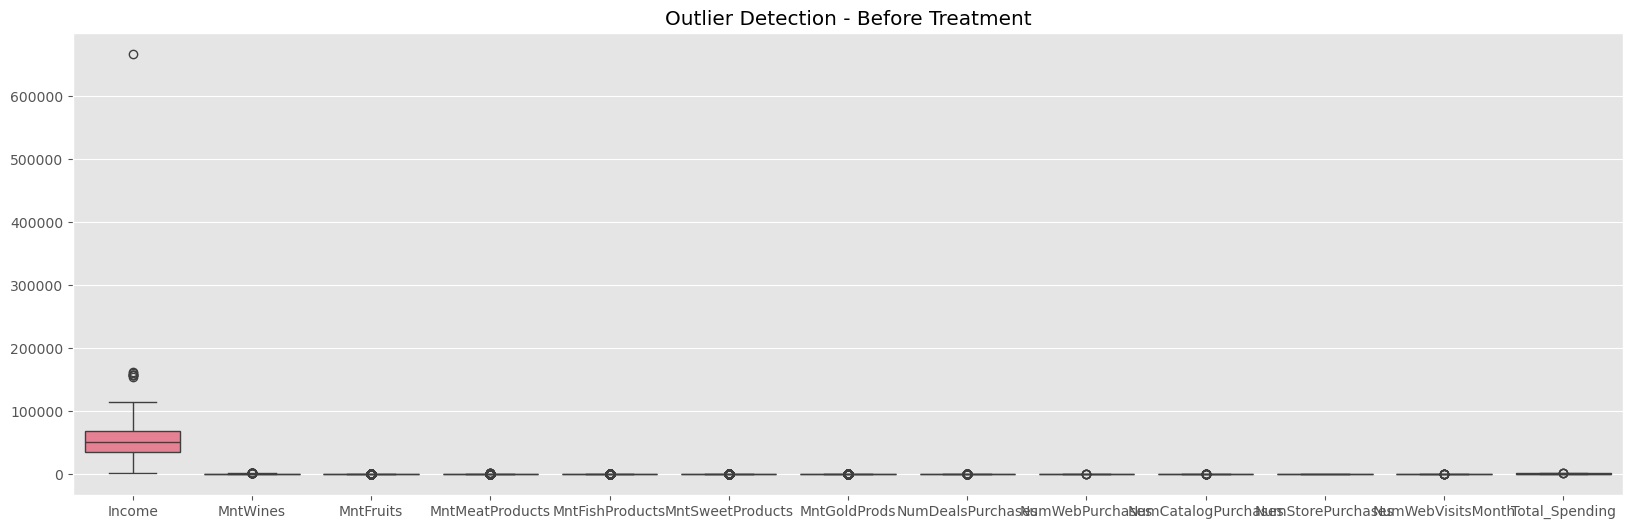

In [16]:
plt.figure(figsize=(20,6))
sns.boxplot(data=df[['Income',  'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending']])
plt.title("Outlier Detection - Before Treatment")
plt.show()

In [17]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

for col in ['Income',  'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending']:
    df = remove_outliers_iqr(df, col)

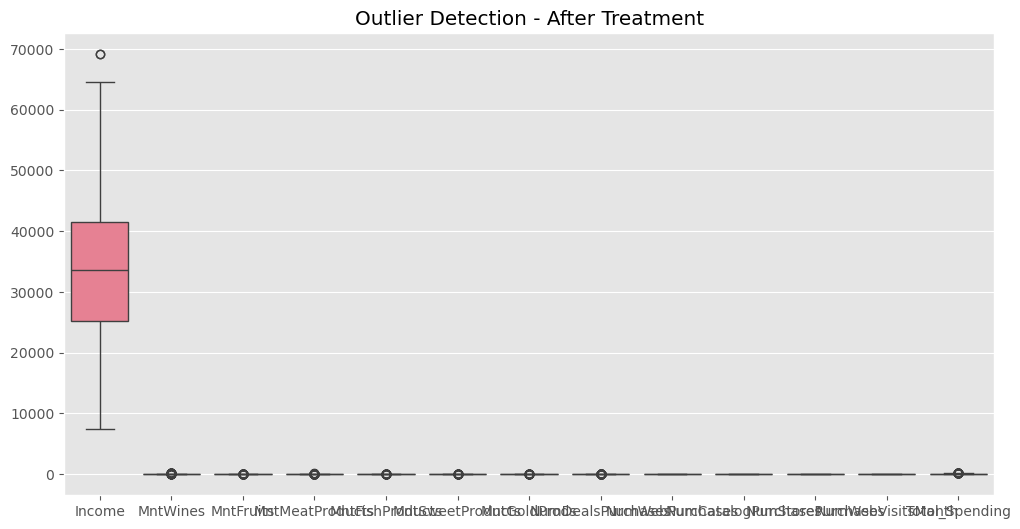

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Income',  'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending']])
plt.title("Outlier Detection - After Treatment")
plt.show()

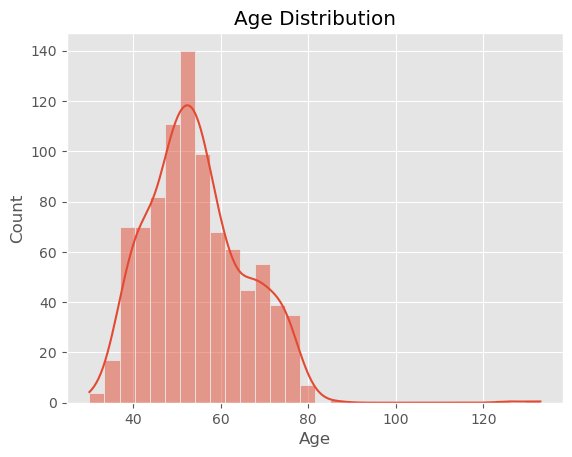

In [19]:
sns.histplot(df['Age'], kde=True, bins=30)
plt.title("Age Distribution")
plt.show()

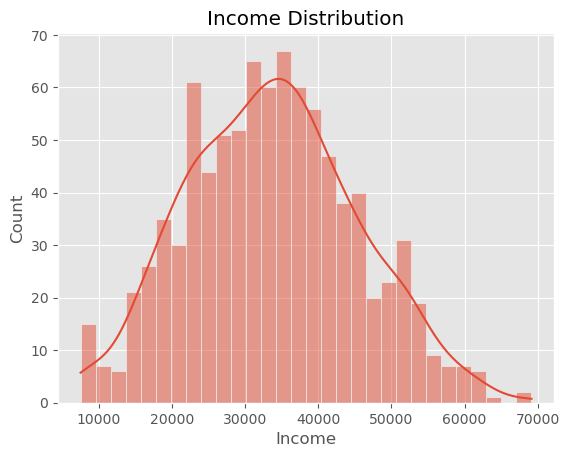

In [20]:
sns.histplot(df['Income'], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

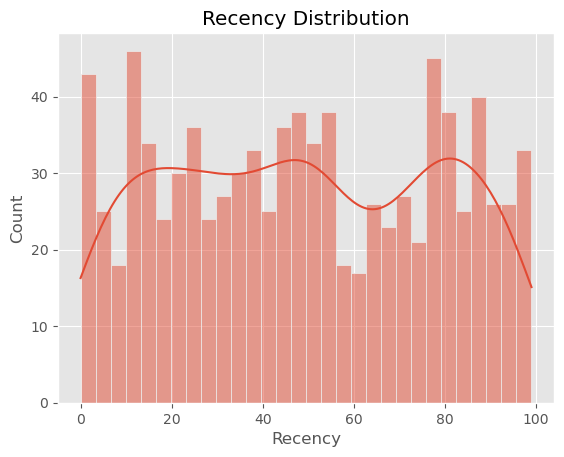

In [21]:
sns.histplot(df['Recency'], kde=True, bins=30)
plt.title("Recency Distribution")
plt.show()

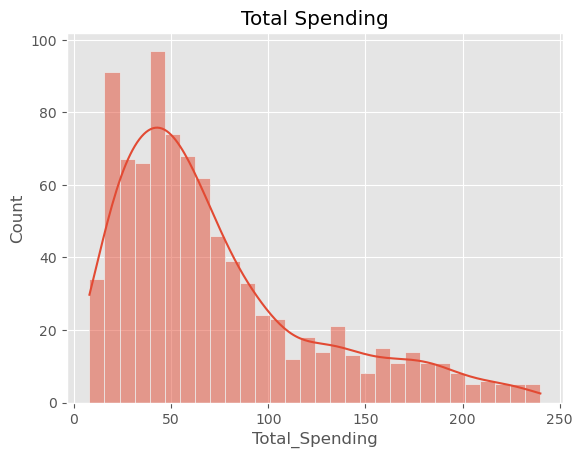

In [22]:
sns.histplot(df['Total_Spending'], kde=True, bins=30)
plt.title("Total Spending")
plt.show()

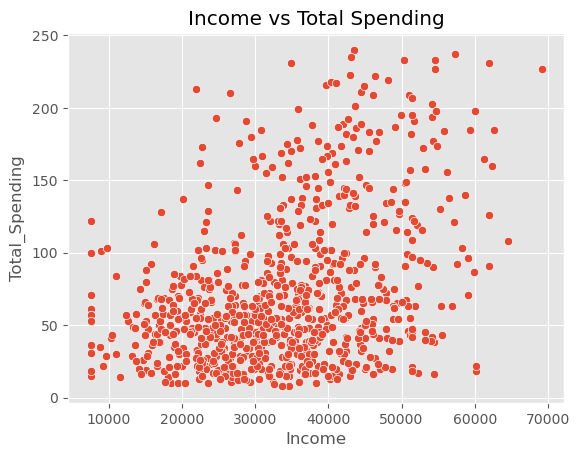

In [23]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.title("Income vs Total Spending")
plt.show()

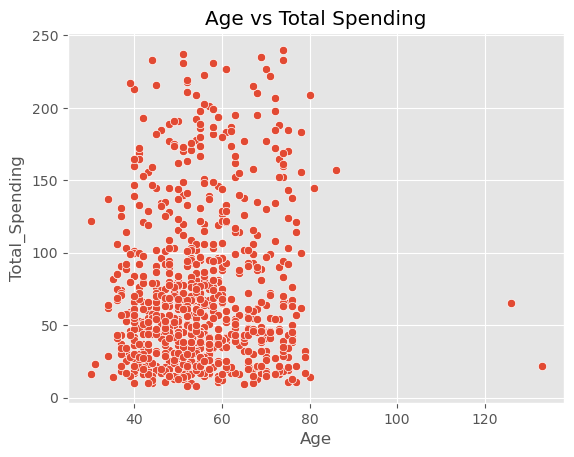

In [24]:
sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.title("Age vs Total Spending")
plt.show()

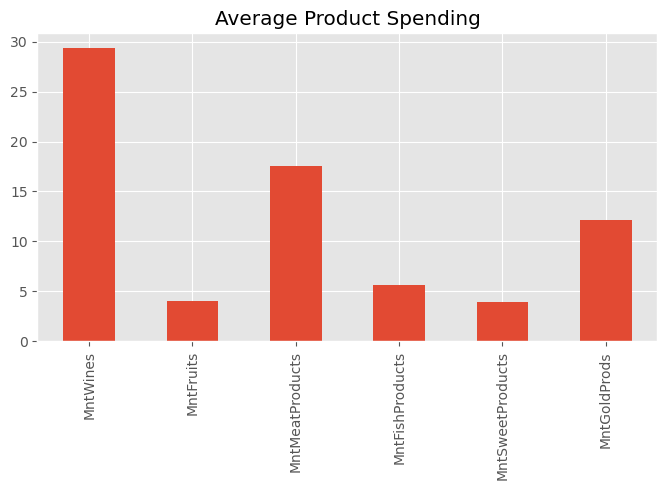

In [25]:
product_cols = ['MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds']

df[product_cols].mean().plot(kind='bar', figsize=(8,4))
plt.title("Average Product Spending")
plt.show()

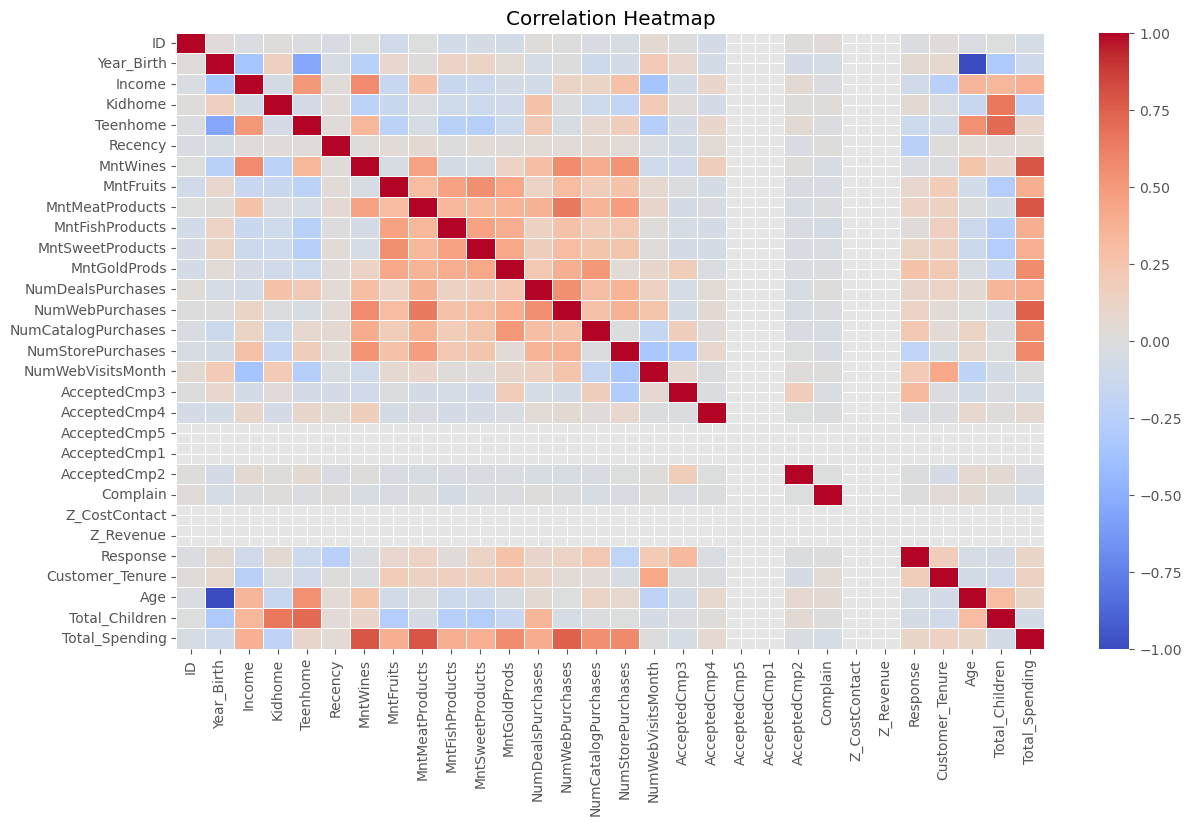

In [26]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

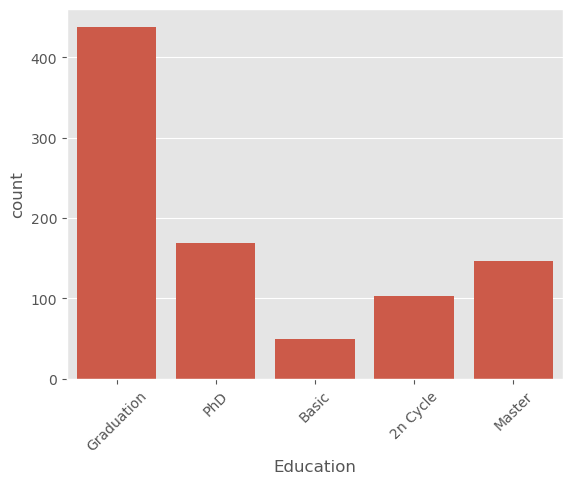

In [27]:
sns.countplot(x='Education', data=df)
plt.xticks(rotation=45)
plt.show()

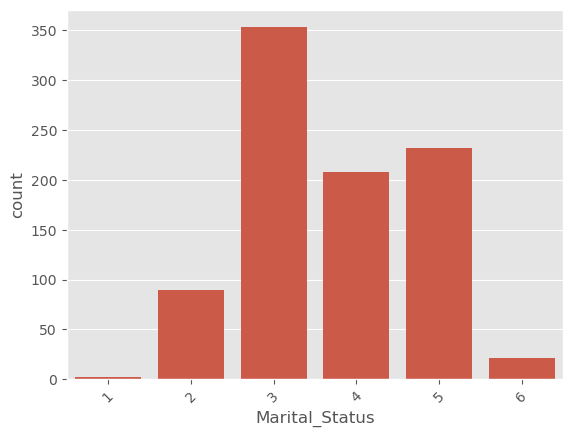

In [28]:
sns.countplot(x='Marital_Status', data=df)
plt.xticks(rotation=45)
plt.show()

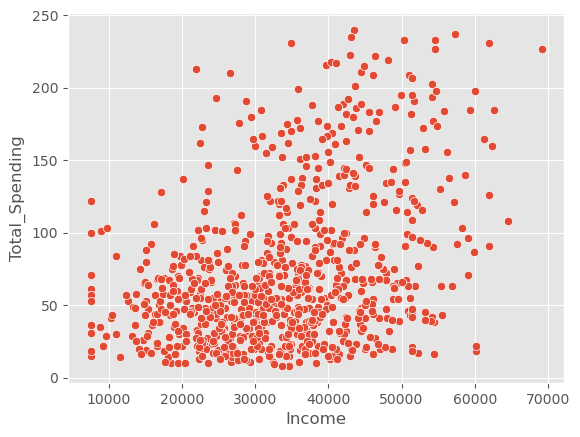

In [29]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.show()

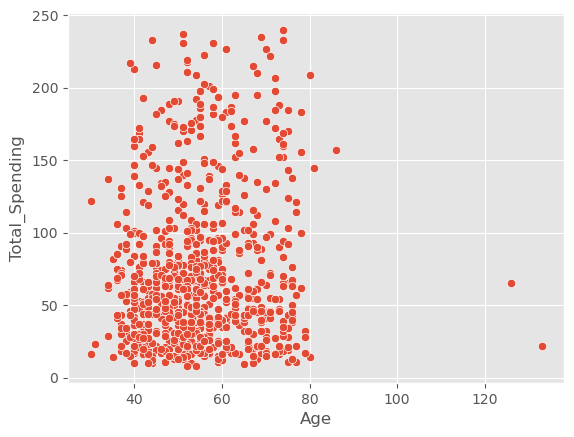

In [30]:
sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.show()

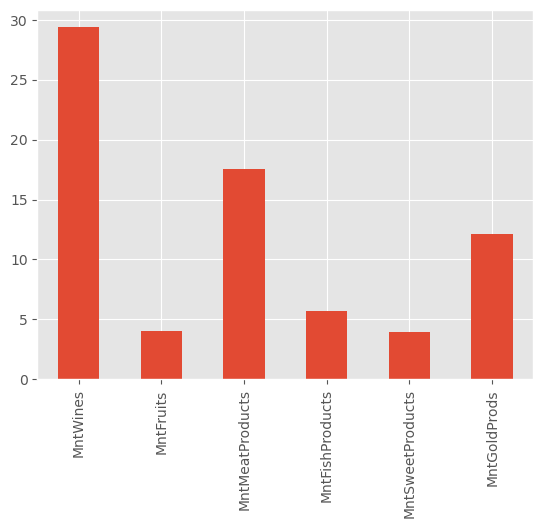

In [31]:
product_cols = ['MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds']

df[product_cols].mean().plot(kind='bar')
plt.show()

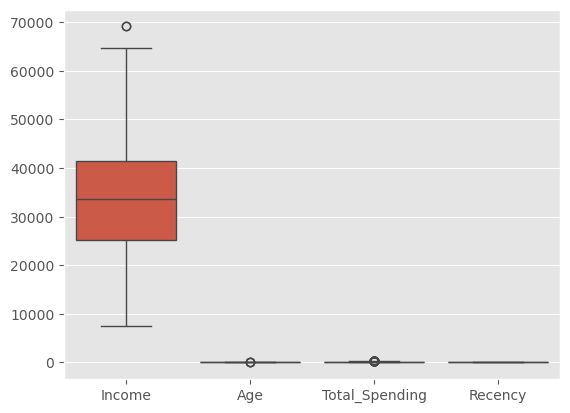

In [32]:
sns.boxplot(data=df[['Income','Age','Total_Spending','Recency']])
plt.show()

In [33]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Customer_Tenure', 'Age', 'Total_Children', 'Total_Spending',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD'],
      dtype='object')

#### Model Building

In [34]:
# feature scaling

features = df[['Income','Age','Recency','Total_Spending',
               'NumWebPurchases','NumStorePurchases',
               'NumCatalogPurchases','NumWebVisitsMonth']]

In [35]:
features.head()

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth
1,46344.0,72,38,27,1,2,1,5
3,26646.0,42,26,53,2,4,0,6
7,33454.0,41,32,169,4,4,0,8
8,30351.0,52,19,46,3,2,0,9
10,51381.5,43,11,19,1,2,0,7


In [36]:
features.shape

(906, 8)

In [37]:
# Create Scaler Object

scaler = StandardScaler()

# Apply feature scaling
X_scaled = scaler.fit_transform(features)

# Convert scaled data to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=features.columns)

X_scaled.head()

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth
0,1.090545,1.526377,-0.377371,-0.882370,-0.875753,-1.373834,1.038579,-0.886624
1,-0.608683,-1.102539,-0.790375,-0.380314,0.132420,1.274451,-0.730129,-0.261502
2,-0.021398,-1.190169,-0.583873,1.859627,2.148767,1.274451,-0.730129,0.988741
3,-0.289075,-0.226234,-1.031294,-0.515483,1.140593,-1.373834,-0.730129,1.613863
4,1.525100,-1.014908,-1.306630,-1.036849,-0.875753,-1.373834,-0.730129,0.363619


In [38]:
# Check Mean and Standard Deviation

X_scaled.describe()

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth
count,9.060000e+02,9.060000e+02,9.060000e+02,9.060000e+02,9.060000e+02,9.060000e+02,9.060000e+02,9.060000e+02
mean,8.626899e-17,-2.176331e-16,-1.161690e-16,1.019543e-16,-9.607228e-17,5.489845e-17,-8.822964e-18,-1.597937e-16
std,1.000552e+00,1.000552e+00,1.000552e+00,1.000552e+00,1.000552e+00,1.000552e+00,1.000552e+00,1.000552e+00
min,-2.260293e+00,-2.154105e+00,-1.685217e+00,-1.249257e+00,-1.883926e+00,-1.373834e+00,-7.301290e-01,-3.387112e+00
25%,-7.307465e-01,-6.643864e-01,-8.592091e-01,-7.085816e-01,-8.757531e-01,-4.969189e-02,-7.301290e-01,-8.866243e-01
50%,-1.169291e-02,-1.386032e-01,1.215611e-03,-3.030750e-01,1.324201e-01,-4.969189e-02,-7.301290e-01,3.636194e-01
75%,6.682184e-01,5.624409e-01,9.304743e-01,4.113891e-01,1.140593e+00,1.274451e+00,1.038579e+00,9.887413e-01
max,3.056933e+00,6.871838e+00,1.722065e+00,3.230626e+00,3.156940e+00,2.598593e+00,2.807288e+00,2.238985e+00


In [39]:
# KMeans Clustering

In [40]:
# Elbow Method
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

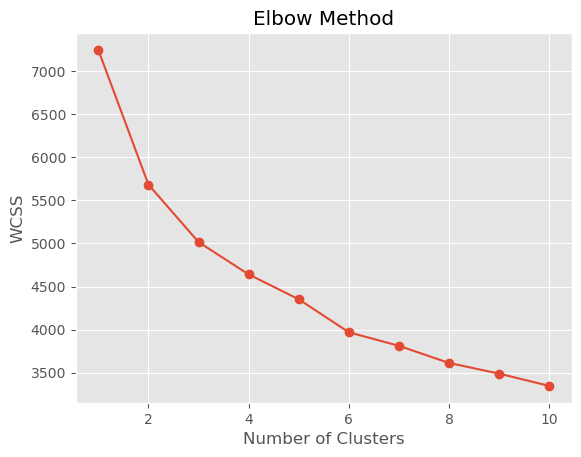

In [41]:
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [42]:
# Apply KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

In [43]:
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [44]:
# Cluster summary

df.groupby('Cluster')[['Income','Age','Total_Spending']].mean()

,Income,Age,Total_Spending
Cluster,,,
0,39191.282609,60.665552,48.913043
1,26023.002381,48.857143,51.788095
2,42172.197861,57.711230,157.679144


In [45]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [46]:
pca_df

,PC1,PC2,Cluster
0,-0.336855,2.049384,0
1,-0.303255,-0.405577,1
2,1.879971,-2.398455,2
3,-1.083767,-1.708496,1
4,-1.595321,0.503858,0
...,...,...,...
901,-0.857220,-0.758428,1
902,-0.673390,-2.969420,1
903,-1.862292,1.284682,0
904,-1.685654,0.274517,1


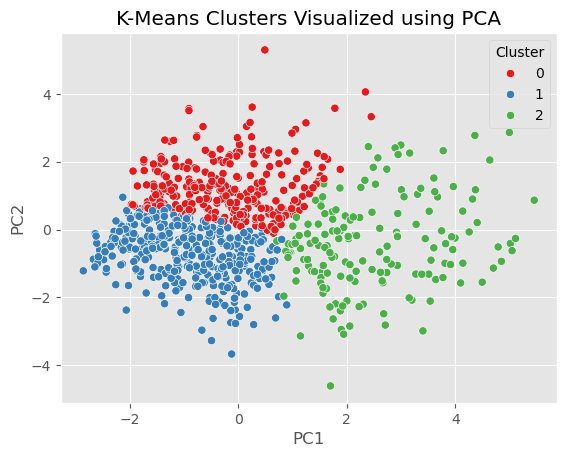

In [47]:
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=pca_df
)

plt.title("K-Means Clusters Visualized using PCA")
plt.show()

In [48]:
import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print("Model saved successfully")

Model saved successfully


In [49]:
# Hierarchical Clustering 

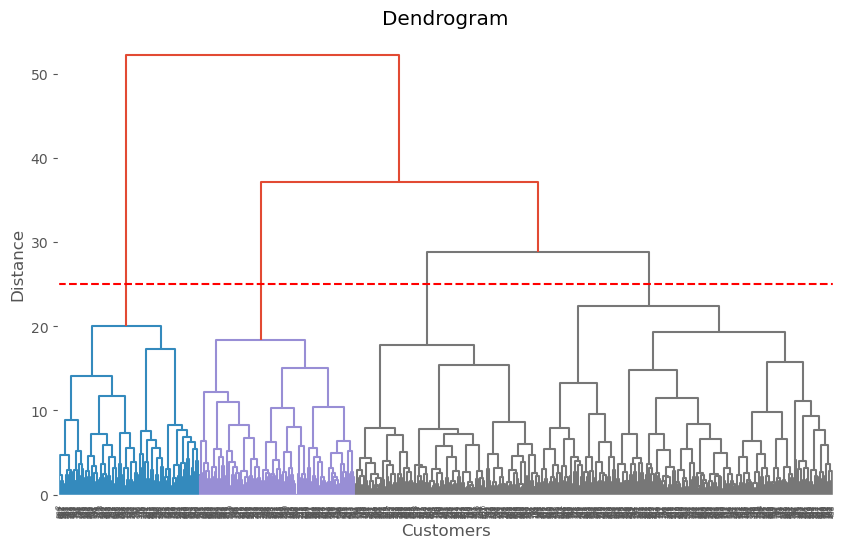

In [50]:
# Dendrogram

plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.axhline(y=25, color='red', linestyle='--')
plt.show()

In [51]:
# Apply Hierarchical Clustering

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')

In [52]:
df['HC_Cluster'] = hc.fit_predict(X_scaled)

In [53]:
# Cluster summary

df.groupby('HC_Cluster')[['Income','Age','Total_Spending']].mean()

,Income,Age,Total_Spending
HC_Cluster,,,
0,35633.089443,58.087977,44.642229
1,43917.018072,58.325301,156.632530
2,29162.557692,54.412088,74.829670
3,26660.652074,46.350230,50.778802


In [54]:
pca_df['HC_Cluster'] = hc.fit_predict(X_scaled)

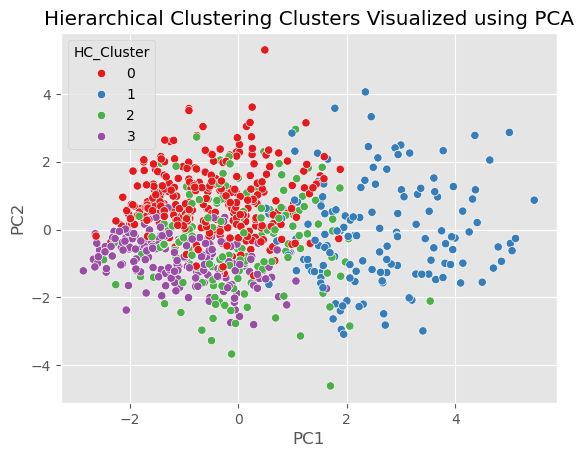

In [55]:
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='HC_Cluster',
    palette='Set1',
    data=pca_df
)

plt.title("Hierarchical Clustering Clusters Visualized using PCA")
plt.show()

In [56]:
from sklearn.cluster import DBSCAN

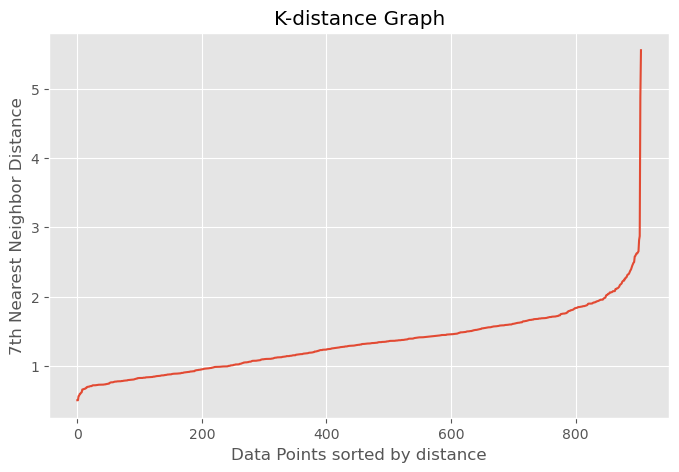

In [57]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=7)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4], axis=0)

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("7th Nearest Neighbor Distance")
plt.show()

In [58]:
dbscan = DBSCAN(eps=1.8, min_samples=7)
clusters = dbscan.fit_predict(X_scaled)
df['DBscan_Cluster'] = clusters

In [59]:
df['DBscan_Cluster'].unique()

array([ 1,  0, -1], dtype=int64)

In [60]:
pca_df['DBscan_Cluster'] = dbscan.fit_predict(X_scaled)

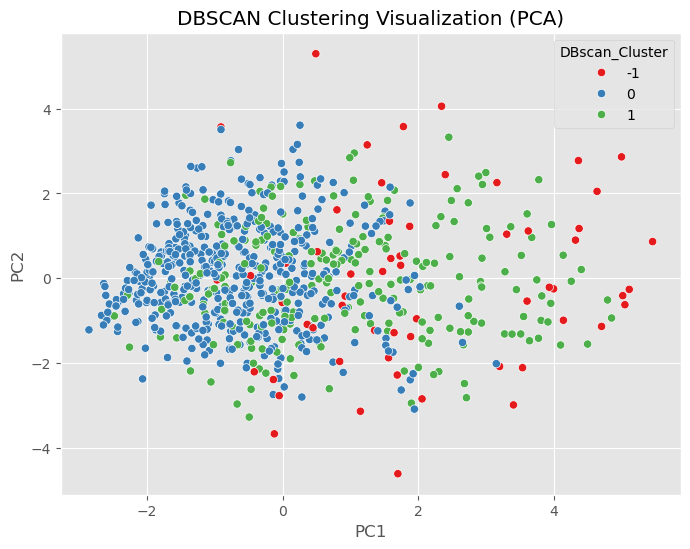

In [61]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='DBscan_Cluster',
    palette='Set1',
    data=pca_df
)

plt.title("DBSCAN Clustering Visualization (PCA)")
plt.show()

#### Model Evaluation

In [62]:
print("K-Means Evaluation")

sil = silhouette_score(X_scaled, df['Cluster'])
db = davies_bouldin_score(X_scaled, df['Cluster'])
ch = calinski_harabasz_score(X_scaled, df['Cluster'])

print("Silhouette Score:", sil)
print("Davies-Bouldin Score:", db)
print("Calinski-Harabasz Score:", ch)

K-Means Evaluation
Silhouette Score: 0.15679539715316723
Davies-Bouldin Score: 1.9281430516083748
Calinski-Harabasz Score: 200.8098466916208


In [63]:
print("Hierarchical Clustering Evaluation")

sil = silhouette_score(X_scaled, df['HC_Cluster'])
db = davies_bouldin_score(X_scaled, df['HC_Cluster'])
ch = calinski_harabasz_score(X_scaled, df['HC_Cluster'])

print("Silhouette Score:", sil)
print("Davies-Bouldin Score:", db)
print("Calinski-Harabasz Score:", ch)

Hierarchical Clustering Evaluation
Silhouette Score: 0.11883149798211656
Davies-Bouldin Score: 1.9888188113693324
Calinski-Harabasz Score: 155.52296517456432


In [64]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

print("DBSCAN Evaluation")

labels = df['DBscan_Cluster'].values

# Remove noise points
mask = labels != -1
X_filtered = X_scaled[mask]
labels_filtered = labels[mask]

unique_clusters = np.unique(labels_filtered)

print("Clusters found:", unique_clusters)

if len(unique_clusters) > 1:
    print("Silhouette Score:", silhouette_score(X_filtered, labels_filtered))
    print("Davies-Bouldin Score:", davies_bouldin_score(X_filtered, labels_filtered))
    print("Calinski-Harabasz Score:", calinski_harabasz_score(X_filtered, labels_filtered))
else:
    print("Not enough clusters for evaluation (DBSCAN produced only one cluster)")

DBSCAN Evaluation
Clusters found: [0 1]
Silhouette Score: 0.18160554073443755
Davies-Bouldin Score: 2.280440252937928
Calinski-Harabasz Score: 138.87588526611887


### K-means performed best

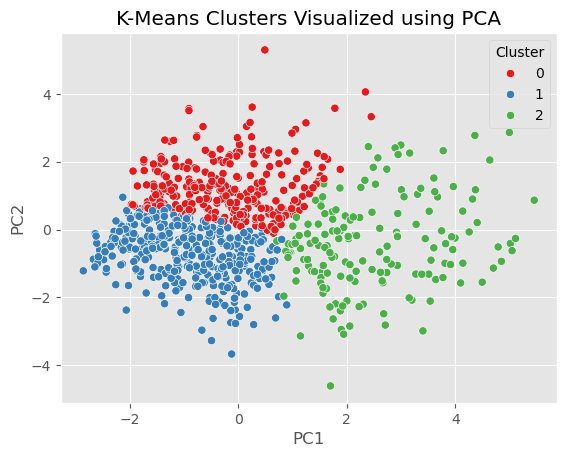

In [65]:
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=pca_df
)

plt.title("K-Means Clusters Visualized using PCA")
plt.show()

In [66]:
# Cluster Profiling

cluster_profile = df.groupby('Cluster')[['Income','Age','Total_Spending']].mean()
print(cluster_profile)

               Income        Age  Total_Spending
Cluster                                         
0        39191.282609  60.665552       48.913043
1        26023.002381  48.857143       51.788095
2        42172.197861  57.711230      157.679144


In [67]:
# Cluster Size

df['Cluster'].value_counts()

Cluster
1    420
0    299
2    187
Name: count, dtype: int64

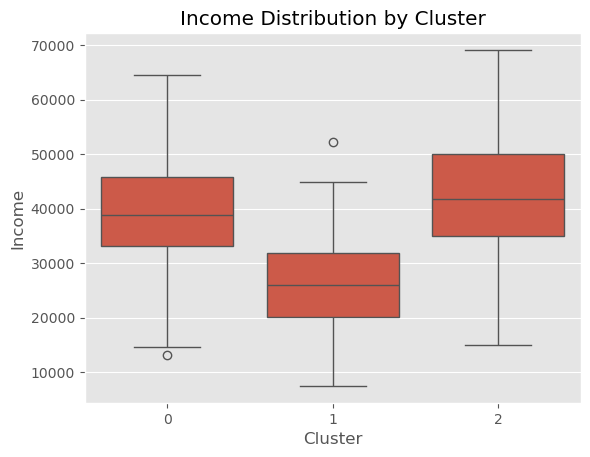

In [68]:
# Boxplot Analysis

sns.boxplot(x='Cluster', y='Income', data=df)

plt.title("Income Distribution by Cluster")

plt.show()

In [69]:
pca_df.to_csv("pca_data.csv", index=False)

In [70]:
pca_df

,PC1,PC2,Cluster,HC_Cluster,DBscan_Cluster
0,-0.336855,2.049384,0,2,1
1,-0.303255,-0.405577,1,0,0
2,1.879971,-2.398455,2,1,0
3,-1.083767,-1.708496,1,3,0
4,-1.595321,0.503858,0,0,0
...,...,...,...,...,...
901,-0.857220,-0.758428,1,2,1
902,-0.673390,-2.969420,1,2,1
903,-1.862292,1.284682,0,0,0
904,-1.685654,0.274517,1,0,0


In [71]:
import pickle

# Save scaler
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

# Save PCA model
with open("pca.pkl","wb") as f:
    pickle.dump(pca,f)



In [72]:
col = list(features.columns)
col.append('Cluster')

cluster_summary = df[col].groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth
Cluster,,,,,,,,
0,39191.282609,60.665552,48.364548,48.913043,1.327759,2.989967,0.280936,5.267559
1,26023.002381,48.857143,48.642857,51.788095,1.771429,2.761905,0.257143,7.276190
2,42172.197861,57.711230,50.647059,157.679144,2.951872,3.732620,0.973262,6.331551


In [73]:
features

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth
1,46344.0,72,38,27,1,2,1,5
3,26646.0,42,26,53,2,4,0,6
7,33454.0,41,32,169,4,4,0,8
8,30351.0,52,19,46,3,2,0,9
10,51381.5,43,11,19,1,2,0,7
...,...,...,...,...,...,...,...,...
2229,24434.0,54,9,50,2,2,1,7
2230,11012.0,42,82,84,3,2,1,9
2232,26816.0,40,50,22,0,3,0,4
2234,34421.0,52,81,30,1,2,0,7


In [74]:
X_scaled

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth
0,1.090545,1.526377,-0.377371,-0.882370,-0.875753,-1.373834,1.038579,-0.886624
1,-0.608683,-1.102539,-0.790375,-0.380314,0.132420,1.274451,-0.730129,-0.261502
2,-0.021398,-1.190169,-0.583873,1.859627,2.148767,1.274451,-0.730129,0.988741
3,-0.289075,-0.226234,-1.031294,-0.515483,1.140593,-1.373834,-0.730129,1.613863
4,1.525100,-1.014908,-1.306630,-1.036849,-0.875753,-1.373834,-0.730129,0.363619
...,...,...,...,...,...,...,...,...
901,-0.799499,-0.050973,-1.375464,-0.438244,0.132420,-1.373834,1.038579,0.363619
902,-1.957334,-1.102539,1.136976,0.218291,1.140593,-1.373834,1.038579,1.613863
903,-0.594018,-1.277800,0.035633,-0.978919,-1.883926,-0.049692,-0.730129,-1.511746
904,0.062020,-0.226234,1.102559,-0.824441,-0.875753,-1.373834,-0.730129,0.363619
